# 光散粒噪声标定 (ASD 底噪法)

**实验目的**：扫描探测光功率，从原始时域波形离线计算 Welch PSD → ASD，取平坦区中位数作为底噪，线性拟合 $\mathrm{ASD}_{\mathrm{noise}} = \alpha' P_{\mathrm{probe}} + \beta'$，单位为 $\mathrm{V/\sqrt{Hz}}$。

**原理**：将主磁场大幅偏置使原子 Larmor 频率移出 LIA 探测带宽，此时 LIA 输出仅含光散粒噪声和电噪声。

**数据处理链**：
1. **采集阶段**（cell-5）：DAQ 采集 X/Y 时域波形，完整保存为 `waveforms_P*.npz`
2. **分析阶段**（cell-6）：加载波形 → Welch PSD → 截取平坦区(f < 0.1fs，避开数字抽取滤波器滚降) → sqrt 得 ASD → median 底噪 → 线性拟合

**方法优势**：
- ASD (V/√Hz) 是谱密度，物理意义比积分方差更 fundamental（散粒噪声公式 $S_0 \propto P_{\mathrm{probe}}$ 直接对应）
- 中位数天然抗尖峰干扰，比积分更鲁棒
- 频率截断避开 LPF 滚降区，只取白噪声平台
- 原始数据完整保存，PSD/ASD 参数可随时调整重算

**涉及设备**：
- GS200：主磁场（偏置到 5 mA，远离正常工作点 9.305 mA）
- DG912 Pro (dg_laser)：Pump 光功率 (CH1, 关断)、Probe 光功率 (CH2, 扫描变量)
- DG4000 (dg_temp)：温度开关
- TEC103：气室温度控制
- HF2：锁相放大器 + DAQ 采集 X/Y 时间序列

**参数概览**：
- 扫描变量：Probe_laser_power (0 → 0.1 V, 11 点)
- 温度：100 °C，主磁场：5 mA
- 每点采集时长：1 s，重复 20 次
- PSD: Welch nperseg=4096
- ASD: flat band (0, 0.3fs] Hz, median of sqrt(PSD)

In [53]:
# ========== 交互式绘图模式 ==========
%matplotlib widget

from pathlib import Path
import sys
# 自动定位项目根目录（以 params/ 目录为标记）
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm

# 设备库
from gs200 import GS200Instrument
from signal_generator import DG4000Instrument, DG900Instrument
from tec_controller import TECInstrument
from lockin_amplifier import (
    HF2Instrument, DAQConfig,
    DemodulatorConfig, demod, daq,
)

# 数据分析库
from scipy.optimize import curve_fit
from scipy import signal as scipy_signal

# ========== 实验参数 ==========
EXPERIMENT_TYPE = "Photon_shot_noise"
PURPOSE = "shot_noise_calibration"

print("所有库导入成功")

所有库导入成功


In [54]:
# ========== 加载配置 ==========

# 加载物理量→仪器映射
with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]

# 加载安全限值
with open(project_root / "params" / "safety_limits.yaml", encoding="utf-8") as f:
    LIMITS = yaml.safe_load(f)["safety_limits"]

# ========== 扫描参数 ==========
PROBE_POWER_START = 0.0       # 探测光功率起始 (V)
PROBE_POWER_STOP = 0.3        # 探测光功率终止 (V)
PROBE_POWER_POINTS = 31        # 扫描点数
PROBE_SETTLE_TIME = 0.5       # 每点设置后等待稳定时间 (s)

# ========== 采集参数 ==========
ACQ_DURATION = 1.0             # 每点 DAQ 采集时长 (s)
ACQ_REPEATS = 20               # 每点重复采集次数

# ========== PSD 计算参数 ==========
PSD_NPERSEG = 4096             # Welch PSD 每段点数

# ========== 固定参数 ==========
FIXED_PARAMS = {
    "temperature": 100.0,               # 气室温度 (°C)
    "SHOT_NOISE_FIELD_mA": 5.0,         # 散粒噪声测量用主磁场 (mA)，远离 9.305 mA 正常点
    "Pump_laser_power": 0.0,            # Pump 光功率，关闭
    "Temp_Switch": 5.0,                 # 温度开关常开
}

# ========== HF2 解调参数 ==========
HF2_DEMOD_IDX = 0              # 解调器索引
HF2_OSC_FREQ = 90000           # 振荡器频率 (Hz)
HF2_SIGNAL_RANGE = 2.0         # 信号输入量程 (V)
HF2_DEMOD_ORDER = 4            # 解调滤波器阶数
HF2_DEMOD_TC = 7e-7       # 解调时间常数 (s)
HF2_DEMOD_RATE = 50000         # 解调输出速率 (Sa/s)

# ========== 运行目录命名 ==========
RUN_TAG = "shot_noise_cal"

# 安全边界检查函数
def validate_safety_limit(name, value):
    """检查数值是否在安全范围内，超出则报错"""
    lim = LIMITS.get(name)
    if lim is None:
        return value
    lo, hi = lim["min"], lim["max"]
    if value is not None and (value < lo or value > hi):
        raise ValueError(
            f"[安全拦截] {name}={value} 超出范围 [{lo}, {hi}]"
        )
    return value

print("配置加载完成")

配置加载完成


In [55]:
# ========== 连接设备 ==========

devices = {}

try:
    # ---- GS200: 主磁场 ----
    gs_cfg = MAPPING["main_magnetic_field"]
    gs = GS200Instrument(gs_cfg["resource"])
    gs.connect()
    print(f"GS200 已连接: {gs.idn()}")
    gs.set_source_function(gs_cfg["source_function"])
    gs.set_current_limit(LIMITS["main_magnetic_field"]["max"] / 1000.0)
    devices["gs200"] = gs

    # ---- DG912 Pro: Pump/Probe 光功率 ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG900Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"光功率 DG912 Pro 已连接: {dg_laser.idn()}")
    dg_laser.set_ref_clock_source("EXTernal")
    devices["dg_laser"] = dg_laser

    # ---- DG4000: 温度开关 ----
    dg_temp_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(dg_temp_cfg["resource"], channel=2)
    dg_temp.connect()
    print(f"温控 DG4000 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- TEC103: 温度控制器 ----
    tec_cfg = MAPPING["temperature"]
    tec = TECInstrument(port=tec_cfg["resource"])
    tec.connect()
    print(f"TEC103 已连接")
    devices["tec"] = tec

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    print(f"  -> HF2 时钟源: 外部")
    devices["hf2"] = hfi

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

GS200 已连接: YOKOGAWA,GS210,90Z631552,2.02
光功率 DG912 Pro 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q280100002,00.02.01.00.02
温控 DG4000 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
TEC103 已连接
HF2 已连接: HF2LI
  -> HF2 时钟源: 外部

所有设备连接完成，共 5 个设备


In [56]:
# ========== 设置初始值 ==========

# ---- 1. Pump 光功率 (DC, 关闭) ----
# [经验] 散粒噪声测量需完全关闭 Pump 光，确保无原子极化
validate_safety_limit("Pump_laser_power", FIXED_PARAMS["Pump_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Pump_laser_power"], channel=1)
dg_laser.set_output(False, channel=1)  # 直接关闭输出确保隔离度
print(f"Pump 光功率: CH1 关闭 (输出 OFF)")

# ---- 2. Probe 光功率 (DC, 初始值 0) ----
validate_safety_limit("Probe_laser_power", PROBE_POWER_START)
dg_laser.setup_dc(PROBE_POWER_START, channel=2)
dg_laser.set_output(True, channel=2)
print(f"Probe 光功率: CH2={PROBE_POWER_START} V (输出 ON)")

# ---- 3. 主磁场（偏置到远离正常点）----
# [经验] 将主磁场从正常值 9.305 mA 大幅偏置，使 Ω_L 移出 LIA 探测带宽
validate_safety_limit("main_magnetic_field", FIXED_PARAMS["SHOT_NOISE_FIELD_mA"])
gs.set_current(FIXED_PARAMS["SHOT_NOISE_FIELD_mA"] / 1000.0)
gs.set_output(True)
print(f"主磁场: {FIXED_PARAMS['SHOT_NOISE_FIELD_mA']} mA (偏置，远离正常点 9.305 mA)")

# ---- 4. 温度控制 ----
validate_safety_limit("temperature", FIXED_PARAMS["temperature"])
tec.set_target_temperature(FIXED_PARAMS["temperature"], channel=1)
tec.set_enable(True, channel=1)
temp_now = tec.get_temperature(channel=1)
print(f"温度设定: {FIXED_PARAMS['temperature']} °C, 当前: {temp_now:.1f} °C")
print("等待温度稳定...")
while True:
    time.sleep(5)
    t = tec.get_temperature(channel=1)
    print(f"  当前温度: {t:.2f} °C")
    try:
        t2 = tec.get_temperature(channel=1)
        if abs(t2 - FIXED_PARAMS['temperature']) < 1:
            print(f"温度已稳定: {t2:.2f} °C")
            break
    except:
        pass

# ---- 5. 温度开关 (ON) ----
validate_safety_limit("Temp_Switch", FIXED_PARAMS["Temp_Switch"])
dg_temp.setup_dc(FIXED_PARAMS["Temp_Switch"], channel=2)
dg_temp.set_output(True, channel=2)
print(f"温度开关: ON ({FIXED_PARAMS['Temp_Switch']} V)")

# ---- 6. 配置 HF2 解调器 ----

demod_cfg = DemodulatorConfig(
    demod_index=HF2_DEMOD_IDX, enable=True,
    rate=HF2_DEMOD_RATE, input_channel=0,
    osc_select=0, harmonic=1,
    time_constant=HF2_DEMOD_TC, order=HF2_DEMOD_ORDER,
)
actual_rate = demod.configure_demodulator(hfi, demod_cfg)
print(f"HF2 解调器 {HF2_DEMOD_IDX} 已配置: Rate={HF2_DEMOD_RATE} Sa/s, TC={HF2_DEMOD_TC*1e6:.0f} μs")

# ========== 创建运行目录 ==========
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
raw_dir = run_dir / "raw"
raw_dir.mkdir(exist_ok=True)
results_dir = run_dir / "results"
results_dir.mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

# ========== 保存实验配置 ==========
config = {
    "experiment_type": EXPERIMENT_TYPE,
    "purpose": PURPOSE,
    "timestamp": timestamp,
    "scan_params": {
        "variable": "Probe_laser_power",
        "start": PROBE_POWER_START,
        "stop": PROBE_POWER_STOP,
        "points": PROBE_POWER_POINTS,
        "settle_time": PROBE_SETTLE_TIME,
    },
    "acquisition_params": {
        "duration": ACQ_DURATION,
        "repeats": ACQ_REPEATS,
    },
    "psd_params": {
        "nperseg": PSD_NPERSEG,
    },
    "fixed_params": FIXED_PARAMS,
    "hf2_demod": {
        "demod_idx": HF2_DEMOD_IDX,
        "osc_freq": HF2_OSC_FREQ,
        "signal_range": HF2_SIGNAL_RANGE,
        "order": HF2_DEMOD_ORDER,
        "tc": HF2_DEMOD_TC,
        "rate": HF2_DEMOD_RATE,
    },
}
config_path = run_dir / "experiment_config.yaml"
with open(config_path, "w", encoding="utf-8") as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)
print(f"实验配置已保存: {config_path}")

print("\n初始值设置完成")

Pump 光功率: CH1 关闭 (输出 OFF)
Probe 光功率: CH2=0.0 V (输出 ON)
主磁场: 5.0 mA (偏置，远离正常点 9.305 mA)
温度设定: 100.0 °C, 当前: 100.6 °C
等待温度稳定...
  当前温度: 100.81 °C
温度已稳定: 100.79 °C
温度开关: ON (5.0 V)
HF2 解调器 0 已配置: Rate=50000 Sa/s, TC=1 μs
运行目录: d:\Code\exp_agent\data\Photon_shot_noise\0527_1750_shot_noise_cal
实验配置已保存: d:\Code\exp_agent\data\Photon_shot_noise\0527_1750_shot_noise_cal\experiment_config.yaml

初始值设置完成


In [57]:
# ========== 数据采集：扫描 Probe 光功率 + DAQ 采集 X/Y 时间序列 ==========
# [经验] 采集时关闭温度开关，消除温控 PWM 磁场干扰
# [经验] 原始时域数据完整保存，PSD 计算和拟合在分析 Cell 中进行
# [经验] 高功率点若偏离线性，可能是探测器饱和，需检查 PD 工作点

probe_powers = np.linspace(PROBE_POWER_START, PROBE_POWER_STOP, PROBE_POWER_POINTS)
print("=" * 60)
print(f"光散粒噪声标定 — 探测光功率扫描")
print(f"主磁场 (偏置): {FIXED_PARAMS['SHOT_NOISE_FIELD_mA']} mA")
print(f"探测光功率: {PROBE_POWER_START} → {PROBE_POWER_STOP} V, {PROBE_POWER_POINTS} 点")
print(f"每点采集 {ACQ_REPEATS} 次 × {ACQ_DURATION} s")
print("=" * 60)

grid_cols = int(actual_rate * ACQ_DURATION)
print(f"DAQ grid_cols: {grid_cols} (rate={actual_rate:.0f} Sa/s × {ACQ_DURATION} s)")

t_start = time.time()

pbar = tqdm(total=PROBE_POWER_POINTS, desc="Probe Power", unit="pt")
try:
    for i, pwr in enumerate(probe_powers):
        validate_safety_limit("Probe_laser_power", pwr)

        dg_laser.setup_dc(pwr, channel=2)
        time.sleep(PROBE_SETTLE_TIME)

        power_waveforms = []

        for rep in range(ACQ_REPEATS):
            dg_temp.set_output(False, channel=2)
            time.sleep(0.1)
            daq_cfg = DAQConfig(
                device=MAPPING["lockin_r"]["device_id"],
                trigger_type=0,
                duration=ACQ_DURATION,
                grid_cols=grid_cols,
                grid_rows=1,
                grid_mode=2,
                signal_paths=["sample.x", "sample.y"],
            )

            try:
                results = daq.acquire_data(
                    hfi, daq_cfg, demod_idx=HF2_DEMOD_IDX,
                    actual_rate=actual_rate, timeout=ACQ_DURATION + 10.0,
                )
                x_data = results[0].values
                y_data = results[1].values
            except Exception as e:
                tqdm.write(f"  [P={pwr:.3f}V, rep={rep}] DAQ 采集失败: {e}")
                x_data = np.full(grid_cols, np.nan)
                y_data = np.full(grid_cols, np.nan)

            dg_temp.set_output(True, channel=2)
            time.sleep(2)

            power_waveforms.append({"x": x_data, "y": y_data})

        # 保存原始波形（供后续 PSD 分析使用）
        np.savez(
            raw_dir / f"waveforms_P{i:03d}.npz",
            probe_power=pwr,
            probe_power_index=i,
            x_waveforms=np.array([w["x"] for w in power_waveforms]),
            y_waveforms=np.array([w["y"] for w in power_waveforms]),
            actual_rate=actual_rate,
        )

        # 快速方差估算（仅用于进度显示，不代表最终结果）
        quick_var_x = np.mean([np.var(w["x"]) for w in power_waveforms])
        quick_var_y = np.mean([np.var(w["y"]) for w in power_waveforms])
        pbar.set_postfix_str(
            f"P={pwr:.3f}V, Var(X)≈{quick_var_x:.3e}, Var(Y)≈{quick_var_y:.3e}"
        )
        pbar.update(1)

except Exception as e:
    print(f"\n扫描出错: {e}")
    print("紧急恢复温度开关...")
    dg_temp.set_output(True, channel=2)
    raise

finally:
    pbar.close()
    dg_temp.set_output(True, channel=2)
    print("温度开关已恢复 ON")

# 保存扫描元数据
np.savez(
    raw_dir / "scan_meta.npz",
    probe_powers=probe_powers,
    acq_duration=ACQ_DURATION,
    acq_repeats=ACQ_REPEATS,
    actual_rate=actual_rate,
)
print(f"扫描元数据已保存: {raw_dir / 'scan_meta.npz'}")

elapsed_total = time.time() - t_start
print(f"\n数据采集完成，总耗时: {elapsed_total / 60:.1f} 分钟")

光散粒噪声标定 — 探测光功率扫描
主磁场 (偏置): 5.0 mA
探测光功率: 0.0 → 0.3 V, 31 点
每点采集 20 次 × 1.0 s
DAQ grid_cols: 57565 (rate=57566 Sa/s × 1.0 s)


Probe Power: 100%|██████████| 31/31 [40:28<00:00, 78.34s/pt, P=0.300V, Var(X)≈7.127e-07, Var(Y)≈7.153e-07]

温度开关已恢复 ON
扫描元数据已保存: d:\Code\exp_agent\data\Photon_shot_noise\0527_1750_shot_noise_cal\raw\scan_meta.npz

数据采集完成，总耗时: 40.5 分钟


从 d:\Code\exp_agent\data\Photon_shot_noise\0527_1750_shot_noise_cal\raw\scan_meta.npz 加载元数据

从原始波形计算 PSD → ASD 底噪...
  Welch nperseg=4096
  Flat band: (0, 2878] Hz
  Metric: median(ASD) = median(sqrt(PSD)), units V/√Hz
ASD 底噪计算完成: 31 个功率点
  频率范围: [0, 28783] Hz
PSD domain fit (points 2-30): ASD^2 = a*P + b  [V^2/Hz]
  a_x = 6.220097e-11 +/- 3.407436e-13 (V^2/Hz)/V
  b_x = -4.020901e-13 +/- 2.233126e-14 V^2/Hz
  a_y = 6.218557e-11 +/- 3.206591e-13 (V^2/Hz)/V
  b_y = -3.907144e-13 +/- 1.878829e-14 V^2/Hz
  sqrt(b_x) = 0.000000e+00 V/sqrtHz  (elec. noise ASD)
  sqrt(b_y) = 0.000000e+00 V/sqrtHz


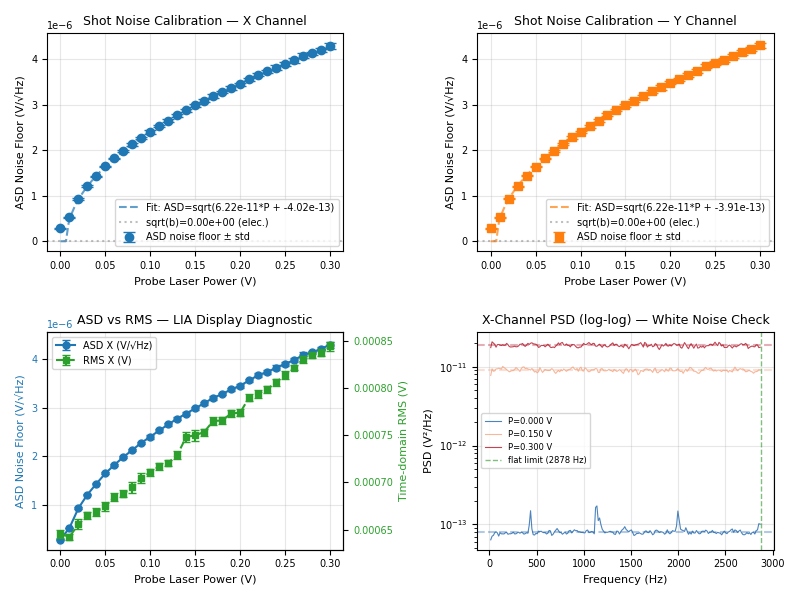

分析结果已保存: d:\Code\exp_agent\data\Photon_shot_noise\0527_1750_shot_noise_cal\results\analysis.yaml


In [58]:
# ========== 数据分析 (ASD 底噪法) ==========
# 从原始时域波形加载，Welch PSD → 截取平坦区 → sqrt 得 ASD
# 取 flat 区 ASD 中位数作为底噪，线性拟合 ASD_noise = α'·P_probe + β'
plt.close('all')
# ---- 加载扫描元数据 ----
meta_path = raw_dir / "scan_meta.npz"
if meta_path.exists():
    meta = np.load(meta_path)
    probe_powers = meta["probe_powers"]
    actual_rate = float(meta["actual_rate"])
    ACQ_REPEATS_used = int(meta["acq_repeats"])
    print(f"从 {meta_path} 加载元数据")
else:
    if "probe_powers" not in dir():
        raise FileNotFoundError(f"找不到 {meta_path}，请先运行数据采集 Cell")
    ACQ_REPEATS_used = ACQ_REPEATS
    print("使用内存变量")

n_powers = len(probe_powers)
FLAT_FREQ_LIMIT = actual_rate * 0.05  # 平坦区频率上限，避开 LPF 滚降区
FIT_START_IDX = 2           # 拟合起始索引（跳过低功率非线性区，0-based）

# ---- 从原始波形计算 Welch PSD，取 flat 区 ASD 中位数 ----
print(f"\n从原始波形计算 PSD → ASD 底噪...")
print(f"  Welch nperseg={PSD_NPERSEG}")
print(f"  Flat band: (0, {FLAT_FREQ_LIMIT:.0f}] Hz")
print(f"  Metric: median(ASD) = median(sqrt(PSD)), units V/√Hz")

all_asd_noise_x = []   # (n_powers, ACQ_REPEATS) — ASD 底噪 (V/√Hz)
all_asd_noise_y = []
all_mean_psd_x = []    # 每个功率点的平均 PSD (V²/Hz)（用于诊断绘图）
all_mean_psd_y = []
freqs_saved = None

for i in range(n_powers):
    wf_path = raw_dir / f"waveforms_P{i:03d}.npz"
    if not wf_path.exists():
        print(f"  ⚠ 缺失: {wf_path.name}")
        continue

    wf_data = np.load(wf_path)
    x_waveforms = wf_data["x_waveforms"]
    y_waveforms = wf_data["y_waveforms"]
    n_reps = x_waveforms.shape[0]

    asd_noise_x_list = []
    asd_noise_y_list = []
    psd_x_accum = []
    psd_y_accum = []

    for rep in range(n_reps):
        x = x_waveforms[rep]
        y = y_waveforms[rep]

        if np.all(np.isnan(x)):
            asd_noise_x_list.append(np.nan)
            asd_noise_y_list.append(np.nan)
            continue

        nperseg = min(PSD_NPERSEG, len(x) // 2)
        freqs, psd_x = scipy_signal.welch(
            x, fs=actual_rate, nperseg=nperseg,
            scaling='density', detrend='constant',
        )
        _, psd_y = scipy_signal.welch(
            y, fs=actual_rate, nperseg=nperseg,
            scaling='density', detrend='constant',
        )

        if freqs_saved is None:
            freqs_saved = freqs

        # 平坦区掩码：排除 DC，截取 LPF 通带内平坦区
        flat_mask = (freqs > 0) & (freqs <= FLAT_FREQ_LIMIT)

        # PSD → ASD (sqrt)，flat 区中位数作为底噪
        asd_x = np.sqrt(np.maximum(psd_x, 0))
        asd_y = np.sqrt(np.maximum(psd_y, 0))
        asd_noise_x_list.append(np.median(asd_x[flat_mask]))
        asd_noise_y_list.append(np.median(asd_y[flat_mask]))
        psd_x_accum.append(psd_x)
        psd_y_accum.append(psd_y)

    all_asd_noise_x.append(asd_noise_x_list)
    all_asd_noise_y.append(asd_noise_y_list)
    all_mean_psd_x.append(np.mean(psd_x_accum, axis=0) if psd_x_accum
                          else np.full_like(freqs_saved, np.nan))
    all_mean_psd_y.append(np.mean(psd_y_accum, axis=0) if psd_y_accum
                          else np.full_like(freqs_saved, np.nan))

# ---- 时域 RMS 参考（LIA 显示对应量，用于与 ASD 底噪对比诊断） ----
all_rms_x = []   # (n_powers, ACQ_REPEATS) — 时域 RMS (V)
all_rms_y = []
for i in range(n_powers):
    wf_path = raw_dir / f"waveforms_P{i:03d}.npz"
    if not wf_path.exists():
        continue
    wf_data = np.load(wf_path)
    x_wf = wf_data["x_waveforms"]
    y_wf = wf_data["y_waveforms"]
    all_rms_x.append([np.std(x_wf[r]) for r in range(x_wf.shape[0])])
    all_rms_y.append([np.std(y_wf[r]) for r in range(y_wf.shape[0])])
all_rms_x = np.array(all_rms_x, dtype=float)
all_rms_y = np.array(all_rms_y, dtype=float)
mean_rms_x = np.nanmean(all_rms_x, axis=1)
std_rms_x = np.nanstd(all_rms_x, axis=1)
mean_rms_y = np.nanmean(all_rms_y, axis=1)
std_rms_y = np.nanstd(all_rms_y, axis=1)

# # ---- 汇总统计 ----
all_asd_noise_x = np.array(all_asd_noise_x, dtype=float)
all_asd_noise_y = np.array(all_asd_noise_y, dtype=float)
mean_asd_x = np.nanmean(all_asd_noise_x, axis=1)
std_asd_x = np.nanstd(all_asd_noise_x, axis=1)
mean_asd_y = np.nanmean(all_asd_noise_y, axis=1)
std_asd_y = np.nanstd(all_asd_noise_y, axis=1)

# 保存 ASD 底噪数据
np.savez(
    raw_dir / "scan_data.npz",
    probe_powers=probe_powers,
    asd_noise_x_matrix=all_asd_noise_x,
    asd_noise_y_matrix=all_asd_noise_y,
    mean_asd_x=mean_asd_x,
    std_asd_x=std_asd_x,
    mean_asd_y=mean_asd_y,
    std_asd_y=std_asd_y,
    psd_nperseg=PSD_NPERSEG,
    flat_freq_limit=FLAT_FREQ_LIMIT,
)

psd_x_matrix = np.array(all_mean_psd_x)
psd_y_matrix = np.array(all_mean_psd_y)
np.savez(
    raw_dir / "psd_summary.npz",
    probe_powers=probe_powers,
    freqs=freqs_saved,
    psd_x_matrix=psd_x_matrix,
    psd_y_matrix=psd_y_matrix,
)
print(f"ASD 底噪计算完成: {n_powers} 个功率点")
print(f"  频率范围: [{freqs_saved[0]:.0f}, {freqs_saved[-1]:.0f}] Hz")

# ---- 线性拟合: ASD_noise = α'·P_probe + β' ----
def linear_model(p, a, b):
    return a * p + b

# X channel: weighted linear fit on ASD^2 (PSD domain)
# 仅用 FIT_START_IDX 之后的数据点拟合，跳过低功率区（光功率线性度差）
p_fit = probe_powers[FIT_START_IDX:]
asd2_x = mean_asd_x[FIT_START_IDX:] ** 2
sigma_asd2_x = 2 * mean_asd_x[FIT_START_IDX:] * std_asd_x[FIT_START_IDX:]
popt_x, pcov_x = curve_fit(linear_model, p_fit, asd2_x,
                           sigma=sigma_asd2_x, absolute_sigma=True)
alpha_x, beta_x = popt_x
perr_x = np.sqrt(np.diag(pcov_x))

# Y channel
asd2_y = mean_asd_y[FIT_START_IDX:] ** 2
sigma_asd2_y = 2 * mean_asd_y[FIT_START_IDX:] * std_asd_y[FIT_START_IDX:]
popt_y, pcov_y = curve_fit(linear_model, p_fit, asd2_y,
                           sigma=sigma_asd2_y, absolute_sigma=True)
alpha_y, beta_y = popt_y
perr_y = np.sqrt(np.diag(pcov_y))

print("=" * 55)
print(f"PSD domain fit (points {FIT_START_IDX}-{n_powers-1}): ASD^2 = a*P + b  [V^2/Hz]")
print(f"  a_x = {alpha_x:.6e} +/- {perr_x[0]:.6e} (V^2/Hz)/V")
print(f"  b_x = {beta_x:.6e} +/- {perr_x[1]:.6e} V^2/Hz")
print(f"  a_y = {alpha_y:.6e} +/- {perr_y[0]:.6e} (V^2/Hz)/V")
print(f"  b_y = {beta_y:.6e} +/- {perr_y[1]:.6e} V^2/Hz")
beta_x_asd = np.sqrt(max(beta_x, 0))
beta_y_asd = np.sqrt(max(beta_y, 0))
print(f"  sqrt(b_x) = {beta_x_asd:.6e} V/sqrtHz  (elec. noise ASD)")
print(f"  sqrt(b_y) = {beta_y_asd:.6e} V/sqrtHz")
print("=" * 55)

# SNR in PSD domain (10*log10)
if beta_x > 0 and alpha_x > 0:
    snr_db = 10 * np.log10(alpha_x * probe_powers[-1] / beta_x)
    print(f"SNR at max power: {snr_db:.1f} dB (PSD ratio)")
else:
    snr_db = None

# ========== 绘图 ==========
_rc_backup = {k: plt.rcParams[k] for k in ['font.size', 'axes.titlesize', 'axes.labelsize', 'xtick.labelsize', 'ytick.labelsize', 'legend.fontsize']}
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9, 'axes.labelsize': 8, 'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7})
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# 图 1: ASD_noise vs P_probe — X
ax1 = axes[0, 0]
p_fine = np.linspace(probe_powers[0], probe_powers[-1], 100)
ax1.errorbar(probe_powers, mean_asd_x, yerr=std_asd_x, fmt='o', capsize=4,
             color='C0', label='ASD noise floor ± std')
ax1.plot(p_fine, np.sqrt(np.maximum(alpha_x * p_fine + beta_x, 0)), '--', color='C0', alpha=0.7,
         label=f'Fit: ASD=sqrt({alpha_x:.2e}*P + {beta_x:.2e})')
ax1.axhline(y=beta_x_asd, color='gray', linestyle=':', alpha=0.5, label=f'sqrt(b)={beta_x_asd:.2e} (elec.)')
ax1.legend(fontsize=7)
ax1.set_xlabel('Probe Laser Power (V)')
ax1.set_ylabel('ASD Noise Floor (V/√Hz)')
ax1.set_title('Shot Noise Calibration — X Channel')
ax1.grid(True, alpha=0.3)

# 图 2: ASD_noise vs P_probe — Y
ax2 = axes[0, 1]
ax2.errorbar(probe_powers, mean_asd_y, yerr=std_asd_y, fmt='s', capsize=4,
             color='C1', label='ASD noise floor ± std')
ax2.plot(p_fine, np.sqrt(np.maximum(alpha_y * p_fine + beta_y, 0)), '--', color='C1', alpha=0.7,
         label=f'Fit: ASD=sqrt({alpha_y:.2e}*P + {beta_y:.2e})')
ax2.axhline(y=beta_y_asd, color='gray', linestyle=':', alpha=0.5, label=f'sqrt(b)={beta_y_asd:.2e} (elec.)')
ax2.legend(fontsize=7)
ax2.set_xlabel('Probe Laser Power (V)')
ax2.set_ylabel('ASD Noise Floor (V/√Hz)')
ax2.set_title('Shot Noise Calibration — Y Channel')
ax2.grid(True, alpha=0.3)

# 图 3: ASD 底噪 vs 时域 RMS 对比（诊断用）
# LIA 显示对应时域 RMS，若 ASD 无趋势但 RMS 有趋势 → ASD 处理链有问题
ax3 = axes[1, 0]
# 左轴: ASD
ax3.errorbar(probe_powers, mean_asd_x, yerr=std_asd_x, fmt='o-', capsize=3,
             color='C0', label='ASD X (V/√Hz)', markersize=5)
ax3.set_xlabel('Probe Laser Power (V)')
ax3.set_ylabel('ASD Noise Floor (V/√Hz)', color='C0')
ax3.tick_params(axis='y', labelcolor='C0')
# 右轴: RMS
ax3r = ax3.twinx()
ax3r.errorbar(probe_powers, mean_rms_x, yerr=std_rms_x, fmt='s--', capsize=3,
              color='C2', label='RMS X (V)', markersize=5)
ax3r.set_ylabel('Time-domain RMS (V)', color='C2')
ax3r.tick_params(axis='y', labelcolor='C2')
# 合并图例
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3r.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper left')
ax3.set_title('ASD vs RMS — LIA Display Diagnostic')
ax3.grid(True, alpha=0.3)

# 图 4-6: 频谱诊断
sel_idx = [0, n_powers // 2, -1]
sel_labels = [f'P={probe_powers[i]:.3f} V' for i in sel_idx]
sel_colors = ['#2166ac', '#f4a582', '#b2182b']

# 图 4: X PSD log-log（白噪声检验）
ax4 = axes[1, 1]
for idx, label, color in zip(sel_idx, sel_labels, sel_colors):
    flat_mask_plot = (freqs_saved > 0) & (freqs_saved <= FLAT_FREQ_LIMIT)
    ax4.plot(freqs_saved[flat_mask_plot], psd_x_matrix[idx][flat_mask_plot],
               color=color, alpha=0.8, linewidth=0.8, label=label)
    ax4.axhline(y=np.median(psd_x_matrix[idx][flat_mask_plot]),
                color=color, linestyle='--', alpha=0.35)
ax4.set_yscale('log')
ax4.axvline(FLAT_FREQ_LIMIT, color='green', alpha=0.5, linestyle='--', linewidth=1.0,
            label=f'flat limit ({FLAT_FREQ_LIMIT:.0f} Hz)')
ax4.legend(fontsize=6)
ax4.set_xlabel('Frequency (Hz)')
ax4.set_ylabel('PSD (V²/Hz)')
ax4.set_title('X-Channel PSD (log-log) — White Noise Check')
ax4.grid(True, alpha=0.3)

# 恢复默认字体
plt.rcParams.update(_rc_backup)

plt.tight_layout()
fig.savefig(results_dir / "shot_noise_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

# ========== 保存分析结果 ==========
analysis = {
    "method": "ASD noise floor -> ASD^2 linear fit -> curve sqrt(a*P+b)",
    "units": "ASD (V/sqrtHz), fit in PSD domain (V^2/Hz)",
    "psd_params": {
        "nperseg": PSD_NPERSEG,
        "flat_freq_limit_Hz": float(FLAT_FREQ_LIMIT),
        "flat_freq_limit_ratio": 0.05,
        "fit_start_idx": FIT_START_IDX,  # skip low-power nonlinear region
        "sampling_rate_Sa_s": float(actual_rate),
    },
    "fit_results": {
        "alpha_x_V2_per_Hz_per_V": float(alpha_x),
        "alpha_x_err": float(perr_x[0]),
        "beta_x_V2_per_Hz": float(beta_x),
        "beta_x_err": float(perr_x[1]),
        "beta_x_ASD_V_per_sqrtHz": float(beta_x_asd),
        "alpha_y_V2_per_Hz_per_V": float(alpha_y),
        "alpha_y_err": float(perr_y[0]),
        "beta_y_V2_per_Hz": float(beta_y),
        "beta_y_err": float(perr_y[1]),
        "beta_y_ASD_V_per_sqrtHz": float(beta_y_asd),
    },
    "snr_at_max_power_db": float(snr_db) if snr_db is not None else None,
    "validation": {
        "shot_noise_dominant": snr_db >= 6 if snr_db is not None else False,
        "recommended_min_power_V": float(beta_x / alpha_x * 4) if alpha_x > 0 and beta_x > 0 else None,
    },
}
analysis_path = results_dir / "analysis.yaml"
with open(analysis_path, "w", encoding="utf-8") as f:
    yaml.dump(analysis, f, default_flow_style=False, allow_unicode=True)
print(f"分析结果已保存: {analysis_path}")

In [59]:
# ========== 安全断开 ==========

print("正在断开设备...")
print("（所有设备输出状态保持当前设置不变）")

for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name} 已断开")
        except Exception as e:
            print(f"  {name} 断开失败: {e}")

print("所有设备已断开")

正在断开设备...
（所有设备输出状态保持当前设置不变）
  gs200 已断开
  dg_laser 已断开
  dg_temp 已断开
  tec 已断开
  hf2 已断开
所有设备已断开
